# Conjugate Priors and the Bayesian Workflow

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain what **conjugacy** means and why it is useful for Bayesian inference.
2. Derive the **Beta-Binomial**, **Normal-Normal**, and **Gamma-Poisson** conjugate updates.
3. Interpret prior hyperparameters as **pseudo-counts** or **prior data**.
4. Distinguish between **flat**, **weakly informative**, and **informative** priors and choose appropriately.
5. Execute the **Bayesian workflow**: prior predictive check, fit, posterior predictive check, iterate.
6. Visualise how different priors converge to similar posteriors as data accumulates.

## Prerequisites

- [01_bayes_theorem_revisited](01_bayes_theorem_revisited.ipynb) — Prior, likelihood, posterior, Bayes' theorem
- [Module 02 — Distributions](../02_distributions/01_discrete_distributions.ipynb) — Beta, Binomial, Normal, Gamma, Poisson PDFs/PMFs
- Basic calculus (completing the square, recognising distribution kernels)

In [ ]:
# Environment detection & setup
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

# Ensure MiKTeX is on PATH (Windows — conda env may not inherit system PATH)
_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Apply course style
sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    """Notebook-level configuration: paths, LaTeX detection, Manim defaults."""

    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("\u26a0 LaTeX not found \u2014 MathTex will fall back to Text().")

    # \u2500\u2500 Manim helpers \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    def apply_manim_config(self):
        """Call after `from manim import *` to configure Manim for notebook use."""
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr: str, **kwargs):
        """MathTex if LaTeX is available, otherwise a cleaned-up Text fallback."""
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        plain = (
            expr.replace(r"\hat{P}", "P\u0302").replace(r"\text{", "").replace("}", "")
        )
        plain = plain.replace("$", "")
        return Text(plain, **kwargs)

    def save_gifs(self, clean: bool = True):
        """Copy final GIFs to media/gifs/ at repo root and optionally clean local temp files."""
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Conjugacy: When the Posterior Stays in the Family

Recall Bayes' theorem in the continuous-parameter form:

$$
p(\theta \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid \theta)\, p(\theta)}{p(\mathbf{x})} \propto p(\mathbf{x} \mid \theta)\, p(\theta)
$$

The normalising constant $p(\mathbf{x}) = \int p(\mathbf{x} \mid \theta)\, p(\theta)\, d\theta$ is often an intractable integral. This is the fundamental computational challenge of Bayesian inference.

**Conjugacy** provides an elegant escape hatch.

> **Definition (Conjugate prior).** A family $\mathcal{F}$ of prior distributions is *conjugate* to a likelihood $p(\mathbf{x} \mid \theta)$ if, for every prior $p(\theta) \in \mathcal{F}$ and every observed dataset $\mathbf{x}$, the posterior $p(\theta \mid \mathbf{x})$ also belongs to $\mathcal{F}$.

In plain language: **the prior and posterior are the same type of distribution** — only the parameters change. This means:

1. **No integration needed.** The posterior is available in closed form.
2. **No MCMC needed.** We can compute exact credible intervals, posterior means, and predictions.
3. **Sequential updating is trivial.** Today's posterior becomes tomorrow's prior — just update the parameters.
4. **Interpretability.** The prior parameters often have a clear interpretation as "prior data."

The cost? Conjugacy only works for specific likelihood-prior pairs, and the prior family may not capture your actual beliefs. When conjugacy breaks down, we turn to computational methods (grid approximation, MCMC) — the subject of the next two notebooks.

---

## 2. Beta-Binomial Conjugacy

This is the most important conjugate pair in statistics. It arises whenever we observe binary data (success/failure, click/no-click, defective/non-defective) and want to learn about the unknown probability $p$.

### Setup

- **Parameter:** $p \in [0, 1]$ (the probability of success).
- **Prior:** $p \sim \text{Beta}(\alpha, \beta)$ with density

$$
p(p) = \frac{p^{\alpha - 1}(1-p)^{\beta - 1}}{B(\alpha, \beta)}
$$

where $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$ is the Beta function.

- **Likelihood:** We observe $k$ successes in $n$ independent Bernoulli trials:

$$
p(k \mid p) = \binom{n}{k} p^k (1-p)^{n-k}
$$

### Deriving the posterior

Apply Bayes' theorem, keeping only terms that depend on $p$:

$$
p(p \mid k) \propto p(k \mid p)\, p(p) = \binom{n}{k} p^k (1-p)^{n-k} \cdot \frac{p^{\alpha-1}(1-p)^{\beta-1}}{B(\alpha, \beta)}
$$

Drop constants (they don't depend on $p$):

$$
p(p \mid k) \propto p^{k + \alpha - 1}(1-p)^{n - k + \beta - 1}
$$

This is the **kernel** of a Beta distribution! By the uniqueness of probability distributions, we can read off the posterior immediately:

$$
\boxed{p \mid k \sim \text{Beta}(\alpha + k,\; \beta + n - k)}
$$

The prior was $\text{Beta}(\alpha, \beta)$ and the posterior is $\text{Beta}(\alpha', \beta')$ — same family, updated parameters. **This is conjugacy.**

### The pseudo-count interpretation

The update rule has a beautifully simple interpretation:

| Quantity             | Prior            | Data    | Posterior            |
|----------------------|------------------|---------|----------------------|
| Successes            | $\alpha$         | $k$     | $\alpha + k$         |
| Failures             | $\beta$          | $n - k$ | $\beta + n - k$      |
| Total "observations" | $\alpha + \beta$ | $n$     | $\alpha + \beta + n$ |

The prior parameters $\alpha$ and $\beta$ act as **pseudo-counts** — imaginary observations from before the experiment. A $\text{Beta}(1, 1)$ prior (which is Uniform on $[0, 1]$) corresponds to having seen 1 pseudo-success and 1 pseudo-failure. A $\text{Beta}(10, 10)$ prior is like having already seen 10 successes and 10 failures — it encodes a belief that $p \approx 0.5$.

### Posterior mean as a weighted average

The posterior mean is:

$$
E[p \mid k] = \frac{\alpha + k}{\alpha + \beta + n} = \frac{\alpha + \beta}{\alpha + \beta + n} \cdot \underbrace{\frac{\alpha}{\alpha + \beta}}_{\text{prior mean}} + \frac{n}{\alpha + \beta + n} \cdot \underbrace{\frac{k}{n}}_{\text{MLE}}
$$

The posterior mean is a **weighted average** of the prior mean and the maximum likelihood estimate (the sample proportion), with weights proportional to the "sample sizes" ($\alpha + \beta$ for the prior, $n$ for the data). As $n \to \infty$, the data dominates and the posterior concentrates around the MLE — the prior is "washed out."

### Example: A/B testing

A company is testing two versions of a landing page. For **version A**, we observe 47 conversions out of 300 visitors. What is the conversion rate?

We use a weakly informative prior $\text{Beta}(2, 20)$, encoding a prior belief that conversion rates are typically low (prior mean $= 2/22 \approx 0.09$) but with enough uncertainty to let the data speak.

In [2]:
# Beta-Binomial conjugate update: A/B testing example
alpha_prior, beta_prior = 2, 20  # weakly informative prior
n_visitors, k_conversions = 300, 47

# Posterior parameters (the conjugate update!)
alpha_post = alpha_prior + k_conversions
beta_post = beta_prior + n_visitors - k_conversions

prior = stats.beta(alpha_prior, beta_prior)
posterior = stats.beta(alpha_post, beta_post)

print(f"Prior:     Beta({alpha_prior}, {beta_prior})")
print(f"Data:      {k_conversions} conversions in {n_visitors} visitors")
print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"")
print(f"Prior mean:     {prior.mean():.4f}")
print(f"MLE:            {k_conversions / n_visitors:.4f}")
print(f"Posterior mean: {posterior.mean():.4f}")
print(f"95% CI:         ({posterior.ppf(0.025):.4f}, {posterior.ppf(0.975):.4f})")

Prior:     Beta(2, 20)
Data:      47 conversions in 300 visitors
Posterior: Beta(49, 273)

Prior mean:     0.0909
MLE:            0.1567
Posterior mean: 0.1522
95% CI:         (0.1151, 0.1933)


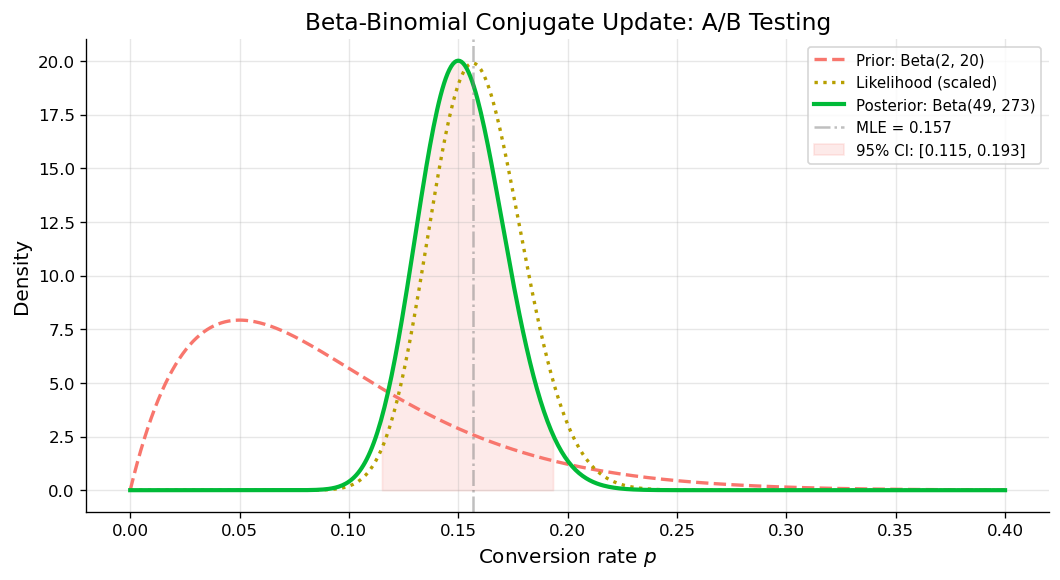

In [ ]:
# Visualise the prior, likelihood, and posterior
p_grid = np.linspace(0, 0.4, 500)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    p_grid,
    prior.pdf(p_grid),
    label=f"Prior: Beta({alpha_prior}, {beta_prior})",
    linewidth=2,
    linestyle="--",
)

# Likelihood (scaled for visual comparison — not a proper density over p)
likelihood = stats.binom.pmf(k_conversions, n_visitors, p_grid)
likelihood_scaled = likelihood / likelihood.max() * posterior.pdf(posterior.mean())
ax.plot(
    p_grid, likelihood_scaled, label="Likelihood (scaled)", linewidth=2, linestyle=":"
)

ax.plot(
    p_grid,
    posterior.pdf(p_grid),
    label=f"Posterior: Beta({alpha_post}, {beta_post})",
    linewidth=2.5,
)

ax.axvline(
    k_conversions / n_visitors,
    color="gray",
    linestyle="-.",
    alpha=0.5,
    label=f"MLE = {k_conversions / n_visitors:.3f}",
)

# Shade 95% credible interval
ci_lo, ci_hi = posterior.ppf(0.025), posterior.ppf(0.975)
p_fill = np.linspace(ci_lo, ci_hi, 300)
ax.fill_between(
    p_fill,
    posterior.pdf(p_fill),
    alpha=0.15,
    color="C0",
    label=f"95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]",
)

ax.set_xlabel("Conversion rate $p$")
ax.set_ylabel("Density")
ax.set_title("Beta-Binomial Conjugate Update: A/B Testing")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Notice how the posterior sits between the prior and the likelihood, but much closer to the likelihood — because 300 data points easily overwhelm the prior's 22 pseudo-observations. The 95% credible interval gives us a direct probability statement: *"Given the data and our prior, there is a 95% probability that the true conversion rate lies in this interval."* This is the Bayesian interpretation — contrast it with the frequentist confidence interval, which says nothing about where the parameter "is."

---

## 3. Normal-Normal Conjugacy

When both the data and the prior are normally distributed, the posterior is also Normal. This is the workhorse of Bayesian inference for continuous measurements.

### Setup (known variance)

- **Parameter:** $\mu$ (the population mean).
- **Known:** $\sigma^2$ (the population variance) — we relax this later.
- **Prior:** $\mu \sim N(\mu_0, \sigma_0^2)$
- **Likelihood:** We observe $x_1, \dots, x_n \overset{\text{iid}}{\sim} N(\mu, \sigma^2)$

### Derivation

The joint likelihood of $n$ observations is:

$$
p(\mathbf{x} \mid \mu) \propto \exp\!\left(-\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2\right) = \exp\!\left(-\frac{n}{2\sigma^2}(\bar{x} - \mu)^2\right) \cdot (\text{terms not involving } \mu)
$$

where $\bar{x} = \frac{1}{n}\sum x_i$. The prior contributes:

$$
p(\mu) \propto \exp\!\left(-\frac{1}{2\sigma_0^2}(\mu - \mu_0)^2\right)
$$

Multiplying (and "completing the square" in $\mu$):

$$
p(\mu \mid \mathbf{x}) \propto \exp\!\left(-\frac{1}{2}\left[\frac{n}{\sigma^2} + \frac{1}{\sigma_0^2}\right](\mu - \mu_n)^2\right)
$$

This is the kernel of a Normal distribution. Defining the **precisions** $\tau_0 = 1/\sigma_0^2$ (prior precision) and $\tau_{\text{data}} = n/\sigma^2$ (data precision):

$$
\boxed{\mu \mid \mathbf{x} \sim N\!\left(\mu_n,\; \sigma_n^2\right)}
$$

where:

$$
\sigma_n^2 = \frac{1}{\tau_0 + \tau_{\text{data}}} = \frac{1}{1/\sigma_0^2 + n/\sigma^2}
$$

$$
\mu_n = \sigma_n^2 \left(\tau_0 \mu_0 + \tau_{\text{data}} \bar{x}\right) = \frac{\mu_0 / \sigma_0^2 + n \bar{x} / \sigma^2}{1/\sigma_0^2 + n/\sigma^2}
$$

### Interpretation: precision-weighted average

The posterior mean $\mu_n$ is a **precision-weighted average** of the prior mean and the sample mean:

$$
\mu_n = w_{\text{prior}} \cdot \mu_0 + w_{\text{data}} \cdot \bar{x}
$$

where $w_{\text{prior}} = \tau_0 / (\tau_0 + \tau_{\text{data}})$ and $w_{\text{data}} = \tau_{\text{data}} / (\tau_0 + \tau_{\text{data}})$. The more precise source (smaller variance) gets more weight. As $n \to \infty$, $\tau_{\text{data}} \to \infty$ and the posterior concentrates around $\bar{x}$ — the prior is forgotten.

In [ ]:
# Normal-Normal conjugate update
# Scenario: estimating the mean height of a population
# Known: sigma = 6 cm.  Prior belief: mu ~ N(170, 10^2)

mu_0, sigma_0 = 170, 10  # prior
sigma = 6  # known population std dev
data = rng.normal(175, sigma, size=25)  # simulate 25 observations from true mu=175
n = len(data)
x_bar = data.mean()

# Posterior parameters
tau_0 = 1 / sigma_0**2
tau_data = n / sigma**2
sigma_n2 = 1 / (tau_0 + tau_data)
mu_n = sigma_n2 * (tau_0 * mu_0 + tau_data * x_bar)
sigma_n = np.sqrt(sigma_n2)

print(f"Prior:            N({mu_0}, {sigma_0}^2)")
print(f"Data:             n={n}, x_bar={x_bar:.2f}")
print(f"Posterior:        N({mu_n:.2f}, {sigma_n:.2f}^2)")
print(f"")
print(f"Prior precision:  {tau_0:.6f}")
print(f"Data precision:   {tau_data:.6f}")
print(f"Weight on prior:  {tau_0 / (tau_0 + tau_data):.4f}")
print(f"Weight on data:   {tau_data / (tau_0 + tau_data):.4f}")

Prior:            N(170, 10^2)
Data:             n=25, x_bar=174.79
Posterior:        N(174.72, 1.19^2)

Prior precision:  0.010000
Data precision:   0.694444
Weight on prior:  0.0142
Weight on data:   0.9858


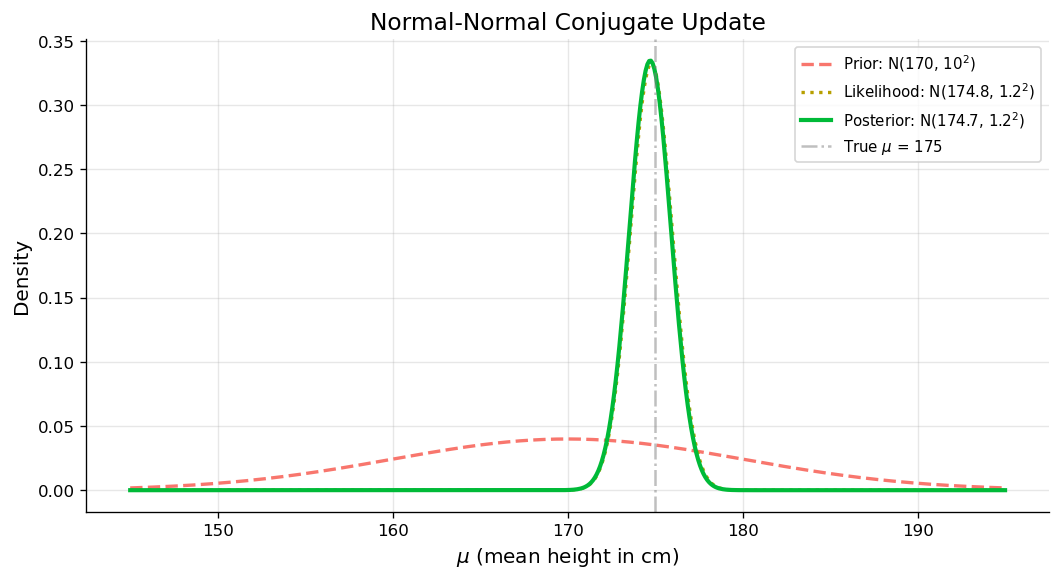

In [ ]:
# Visualise the Normal-Normal update
prior_dist = stats.norm(mu_0, sigma_0)
posterior_dist = stats.norm(mu_n, sigma_n)

x_grid = np.linspace(145, 195, 500)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    x_grid,
    prior_dist.pdf(x_grid),
    "--",
    linewidth=2,
    label=f"Prior: N({mu_0}, {sigma_0}$^2$)",
)

# Likelihood as a function of mu (normal centered at x_bar)
likelihood_dist = stats.norm(x_bar, sigma / np.sqrt(n))
ax.plot(
    x_grid,
    likelihood_dist.pdf(x_grid),
    ":",
    linewidth=2,
    label=f"Likelihood: N({x_bar:.1f}, {sigma / np.sqrt(n):.1f}$^2$)",
)

ax.plot(
    x_grid,
    posterior_dist.pdf(x_grid),
    linewidth=2.5,
    label=f"Posterior: N({mu_n:.1f}, {sigma_n:.1f}$^2$)",
)

ax.axvline(175, color="gray", linestyle="-.", alpha=0.5, label="True $\\mu$ = 175")

ax.set_xlabel("$\\mu$ (mean height in cm)")
ax.set_ylabel("Density")
ax.set_title("Normal-Normal Conjugate Update")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The posterior (solid curve) is narrower than both the prior and the likelihood — combining information always reduces uncertainty. The posterior mean lies between the prior mean and the sample mean, weighted by precision.

---

## 4. Gamma-Poisson Conjugacy

When we model count data with a Poisson likelihood and want to learn about the rate parameter $\lambda$, the Gamma distribution is the conjugate prior.

### Setup

- **Parameter:** $\lambda > 0$ (the rate or intensity).
- **Prior:** $\lambda \sim \text{Gamma}(\alpha, \beta)$ with density

$$
p(\lambda) = \frac{\beta^\alpha}{\Gamma(\alpha)} \lambda^{\alpha - 1} e^{-\beta \lambda}
$$

(using the shape-rate parameterisation: $E[\lambda] = \alpha / \beta$, $\text{Var}(\lambda) = \alpha / \beta^2$).

- **Likelihood:** We observe $x_1, \dots, x_n \overset{\text{iid}}{\sim} \text{Poisson}(\lambda)$:

$$
p(\mathbf{x} \mid \lambda) = \prod_{i=1}^n \frac{e^{-\lambda} \lambda^{x_i}}{x_i!} \propto \lambda^{\sum x_i} e^{-n\lambda}
$$

### Derivation

$$
p(\lambda \mid \mathbf{x}) \propto \lambda^{\sum x_i} e^{-n\lambda} \cdot \lambda^{\alpha - 1} e^{-\beta \lambda} = \lambda^{\alpha + \sum x_i - 1} e^{-(\beta + n)\lambda}
$$

This is the kernel of a Gamma distribution:

$$
\boxed{\lambda \mid \mathbf{x} \sim \text{Gamma}\!\left(\alpha + \textstyle\sum_{i=1}^n x_i,\; \beta + n\right)}
$$

### Interpretation

- $\alpha$ acts as the prior total count (pseudo-observations), $\beta$ as the prior number of observation periods.
- The posterior adds the observed total count $\sum x_i$ and the number of observation periods $n$.
- The posterior mean is $\frac{\alpha + \sum x_i}{\beta + n}$, again a weighted average of the prior mean $\alpha / \beta$ and the sample mean $\bar{x}$.

In [ ]:
# Gamma-Poisson conjugate update
# Scenario: modelling the number of customer support tickets per hour
alpha_prior, beta_prior = 3, 1  # prior: Gamma(3, 1), E[lambda] = 3

# Simulate data from true lambda = 5
true_lambda = 5
data_poisson = rng.poisson(true_lambda, size=20)
n_obs = len(data_poisson)
total_count = data_poisson.sum()

# Posterior
alpha_post_gp = alpha_prior + total_count
beta_post_gp = beta_prior + n_obs

prior_gp = stats.gamma(a=alpha_prior, scale=1 / beta_prior)
posterior_gp = stats.gamma(a=alpha_post_gp, scale=1 / beta_post_gp)

print(
    f"Prior:     Gamma({alpha_prior}, {beta_prior}), E[lambda] = {alpha_prior / beta_prior:.2f}"
)
print(
    f"Data:      n={n_obs}, sum(x) = {total_count}, x_bar = {data_poisson.mean():.2f}"
)
print(
    f"Posterior: Gamma({alpha_post_gp}, {beta_post_gp}), E[lambda] = {alpha_post_gp / beta_post_gp:.2f}"
)
print(f"True lambda: {true_lambda}")

Prior:     Gamma(3, 1), E[lambda] = 3.00
Data:      n=20, sum(x) = 98, x_bar = 4.90
Posterior: Gamma(101, 21), E[lambda] = 4.81
True lambda: 5


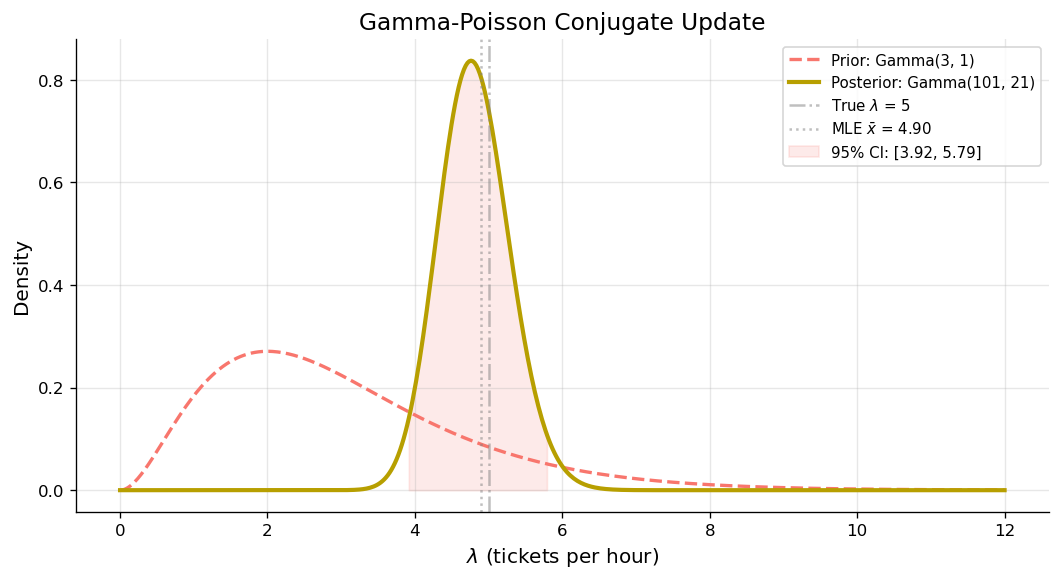

In [ ]:
# Visualise the Gamma-Poisson update
lam_grid = np.linspace(0, 12, 500)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    lam_grid,
    prior_gp.pdf(lam_grid),
    "--",
    linewidth=2,
    label=f"Prior: Gamma({alpha_prior}, {beta_prior})",
)
ax.plot(
    lam_grid,
    posterior_gp.pdf(lam_grid),
    linewidth=2.5,
    label=f"Posterior: Gamma({alpha_post_gp}, {beta_post_gp})",
)
ax.axvline(
    true_lambda,
    color="gray",
    linestyle="-.",
    alpha=0.5,
    label=f"True $\\lambda$ = {true_lambda}",
)
ax.axvline(
    data_poisson.mean(),
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"MLE $\\bar{{x}}$ = {data_poisson.mean():.2f}",
)

# Shade 95% CI
ci_lo_gp, ci_hi_gp = posterior_gp.ppf(0.025), posterior_gp.ppf(0.975)
lam_fill = np.linspace(ci_lo_gp, ci_hi_gp, 300)
ax.fill_between(
    lam_fill,
    posterior_gp.pdf(lam_fill),
    alpha=0.15,
    color="C0",
    label=f"95% CI: [{ci_lo_gp:.2f}, {ci_hi_gp:.2f}]",
)

ax.set_xlabel("$\\lambda$ (tickets per hour)")
ax.set_ylabel("Density")
ax.set_title("Gamma-Poisson Conjugate Update")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Summary of conjugate pairs

| Likelihood                                 | Parameter             | Conjugate Prior                  | Posterior                                          | Update rule                         |
|--------------------------------------------|-----------------------|----------------------------------|----------------------------------------------------|-------------------------------------|
| Binomial$(n, p)$                           | $p$                   | Beta$(\alpha, \beta)$            | Beta$(\alpha + k, \beta + n - k)$                  | Add successes/failures              |
| Normal$(\mu, \sigma^2)$ (known $\sigma^2$) | $\mu$                 | Normal$(\mu_0, \sigma_0^2)$      | Normal$(\mu_n, \sigma_n^2)$                        | Precision-weighted mean             |
| Poisson$(\lambda)$                         | $\lambda$             | Gamma$(\alpha, \beta)$           | Gamma$(\alpha + \sum x_i, \beta + n)$              | Add counts and periods              |
| Normal$(\mu, \sigma^2)$ (known $\mu$)      | $\sigma^2$            | Inverse-Gamma$(\alpha, \beta)$   | Inverse-Gamma$(\alpha + n/2, \beta + \text{SS}/2)$ | Add observations and sum of squares |
| Multinomial$(n, \boldsymbol{\theta})$      | $\boldsymbol{\theta}$ | Dirichlet$(\boldsymbol{\alpha})$ | Dirichlet$(\boldsymbol{\alpha} + \mathbf{k})$      | Add category counts                 |
| Exponential$(\lambda)$                     | $\lambda$             | Gamma$(\alpha, \beta)$           | Gamma$(\alpha + n, \beta + \sum x_i)$              | Add count and total time            |

---

## 5. Types of Priors

Choosing a prior is one of the most important (and controversial) decisions in Bayesian analysis. Here we survey the main categories, their trade-offs, and when to use each.

### 5.1 Flat (uniform) priors

A flat prior assigns equal density to all parameter values: $p(\theta) \propto 1$.

- For the Beta-Binomial: $\text{Beta}(1, 1) = \text{Uniform}(0, 1)$.
- For the Normal mean: $p(\mu) \propto 1$ (improper — doesn't integrate to 1, but the posterior may still be proper).

**Appeal:** "Let the data speak" — the posterior is proportional to the likelihood.

**Problems:**
- Flat priors are **not uninformative**. A uniform prior on $p$ is *not* uniform on $\log(p/(1-p))$ (the log-odds). The prior depends on the parameterisation.
- For unbounded parameters, flat priors are **improper** (infinite total mass). This can lead to improper posteriors in some models.
- They can give unreasonable predictions. A $\text{Beta}(1, 1)$ prior says $p = 0.99$ is just as likely as $p = 0.5$ *a priori* — this is rarely sensible.

**Jeffreys' priors** offer a principled alternative: they are invariant under reparameterisation. For the Binomial, Jeffreys' prior is $\text{Beta}(1/2, 1/2)$ — the arcsine distribution. However, Jeffreys' priors can behave poorly in multi-parameter models, so they are not a universal solution.

### 5.2 Weakly informative priors

A weakly informative prior rules out **implausible** values without strongly favouring any particular value. It gently regularises the inference.

- For a proportion: $\text{Beta}(2, 2)$ — slightly favours moderate values over extremes.
- For a regression coefficient: $N(0, 10^2)$ — allows large effects but regularises toward zero.
- For a scale parameter: Half-Student-$t(\nu = 3, 0, 1)$ — heavy tails accommodate surprise.

This is the **recommended default** in modern Bayesian practice (see Gelman et al., *Bayesian Data Analysis*).

### 5.3 Informative priors

When you have domain knowledge — previous studies, expert opinion, physical constraints — encode it!

- A physician knows that the base rate of a disease is around 1%. Prior: $\text{Beta}(2, 198)$.
- Previous clinical trials measured an effect size of $0.5 \pm 0.2$. Prior: $N(0.5, 0.2^2)$.

Informative priors are not "cheating" — they are a formal mechanism for incorporating existing knowledge. The key is **transparency**: always report your prior, justify it, and check sensitivity.

### Summary table

| Prior type             | Example                              | When to use                                                             | Watch out for                                                           |
|------------------------|--------------------------------------|-------------------------------------------------------------------------|-------------------------------------------------------------------------|
| **Flat / Uniform**     | Beta(1,1), $p(\mu) \propto 1$        | Quick baseline; only if you truly have no information                   | Parameterisation-dependent; can be improper; may give weird predictions |
| **Jeffreys'**          | Beta(0.5, 0.5)                       | Reference analysis; want invariance                                     | Can fail in multi-parameter models                                      |
| **Weakly informative** | $N(0, 10^2)$, Beta(2,2), Half-$t(3)$ | **Default recommendation.** Rules out absurd values, lets data dominate | Still need to check sensitivity                                         |
| **Informative**        | $N(0.5, 0.2^2)$, Beta(2, 198)        | Strong domain knowledge; small samples where prior matters              | Must be transparent and justified; check sensitivity                    |

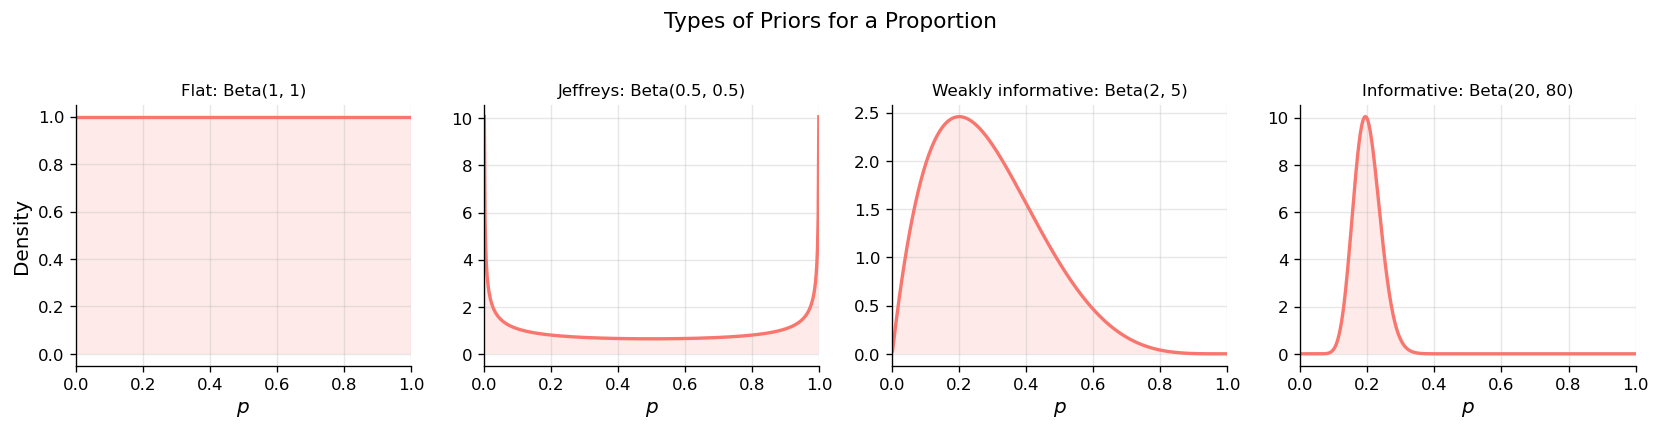

In [8]:
# Visualise the three types of priors for a proportion
p_grid = np.linspace(0.001, 0.999, 500)

priors = {
    "Flat: Beta(1, 1)": stats.beta(1, 1),
    "Jeffreys: Beta(0.5, 0.5)": stats.beta(0.5, 0.5),
    "Weakly informative: Beta(2, 5)": stats.beta(2, 5),
    "Informative: Beta(20, 80)": stats.beta(20, 80),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=False)
for ax, (name, dist) in zip(axes, priors.items()):
    ax.plot(p_grid, dist.pdf(p_grid), linewidth=2)
    ax.fill_between(p_grid, dist.pdf(p_grid), alpha=0.15)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("$p$")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Density")
fig.suptitle("Types of Priors for a Proportion", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. The Bayesian Workflow

Conjugacy gives us tractable posteriors, but a correct posterior from a bad model is still useless. The **Bayesian workflow** (Gelman et al., 2020; Gabry et al., 2019) provides a systematic approach to building, checking, and iterating on Bayesian models.

### The four steps

1. **Choose a model** (likelihood + prior).
2. **Prior predictive check:** Simulate fake datasets from the prior. Do they look like data that *could* plausibly occur in your domain? If the prior produces absurd predictions (e.g., conversion rates above 100%, negative counts), revise.
3. **Fit the model:** Compute the posterior (analytically for conjugate models, or via MCMC).
4. **Posterior predictive check:** Simulate new datasets from the posterior. Does the model reproduce key features of the observed data (mean, variance, shape)? If not, the model is misspecified — go back to step 1.

This is an **iterative cycle**, not a one-shot procedure.

### Worked example: Beta-Binomial workflow

Let's walk through the complete workflow for the coin-flip problem. We observe 7 heads in 10 flips and want to infer the probability of heads.

In [9]:
# === Step 1: Choose model ===
# Likelihood: Binomial(n=10, p)
# Prior: Beta(2, 2) — weakly informative, slightly favours fair coins
alpha_w, beta_w = 2, 2
n_flips, k_heads = 10, 7

print("Step 1: Model")
print(f"  Likelihood: Binomial(n={n_flips}, p)")
print(f"  Prior:      Beta({alpha_w}, {beta_w})")
print(f"  Prior mean: {alpha_w / (alpha_w + beta_w):.2f}")

Step 1: Model
  Likelihood: Binomial(n=10, p)
  Prior:      Beta(2, 2)
  Prior mean: 0.50


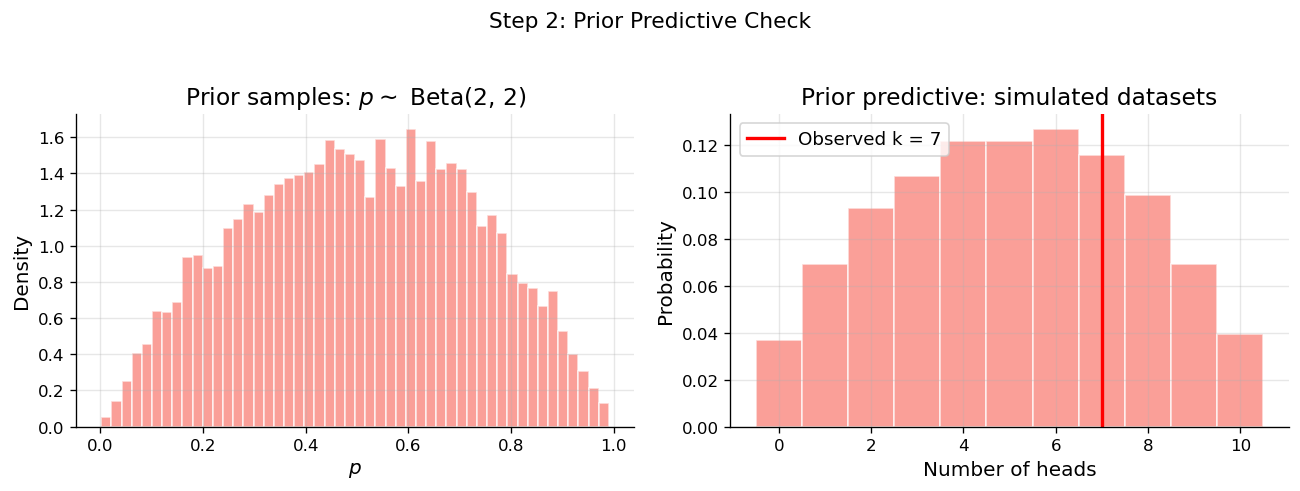

Prior predictive: P(k >= 7) = 0.324
The observed data (7 heads) is plausible under the prior — good.


In [ ]:
# === Step 2: Prior predictive check ===
# Simulate: draw p from the prior, then draw data from Binomial(n, p)
n_sims = 10_000
p_prior_samples = stats.beta(alpha_w, beta_w).rvs(n_sims, random_state=42)
k_prior_pred = np.array([rng.binomial(n_flips, p) for p in p_prior_samples])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Prior distribution on p
ax1.hist(p_prior_samples, bins=50, density=True, alpha=0.7, edgecolor="white")
ax1.set_xlabel("$p$")
ax1.set_ylabel("Density")
ax1.set_title("Prior samples: $p \\sim$ Beta(2, 2)")

# Prior predictive distribution on k
ax2.hist(
    k_prior_pred,
    bins=np.arange(-0.5, n_flips + 1.5),
    density=True,
    alpha=0.7,
    edgecolor="white",
)
ax2.axvline(k_heads, color="red", linewidth=2, label=f"Observed k = {k_heads}")
ax2.set_xlabel("Number of heads")
ax2.set_ylabel("Probability")
ax2.set_title("Prior predictive: simulated datasets")
ax2.legend()

fig.suptitle("Step 2: Prior Predictive Check", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Prior predictive: P(k >= 7) = {np.mean(k_prior_pred >= k_heads):.3f}")
print("The observed data (7 heads) is plausible under the prior — good.")

In [ ]:
# === Step 3: Fit the model (conjugate update) ===
alpha_post_w = alpha_w + k_heads
beta_post_w = beta_w + n_flips - k_heads

posterior_w = stats.beta(alpha_post_w, beta_post_w)

print("Step 3: Posterior")
print(f"  Posterior: Beta({alpha_post_w}, {beta_post_w})")
print(f"  Posterior mean:   {posterior_w.mean():.4f}")
print(f"  Posterior median: {posterior_w.median():.4f}")
print(
    f"  95% CI:           ({posterior_w.ppf(0.025):.4f}, {posterior_w.ppf(0.975):.4f})"
)

Step 3: Posterior
  Posterior: Beta(9, 5)
  Posterior mean:   0.6429
  Posterior median: 0.6498
  95% CI:           (0.3857, 0.8614)


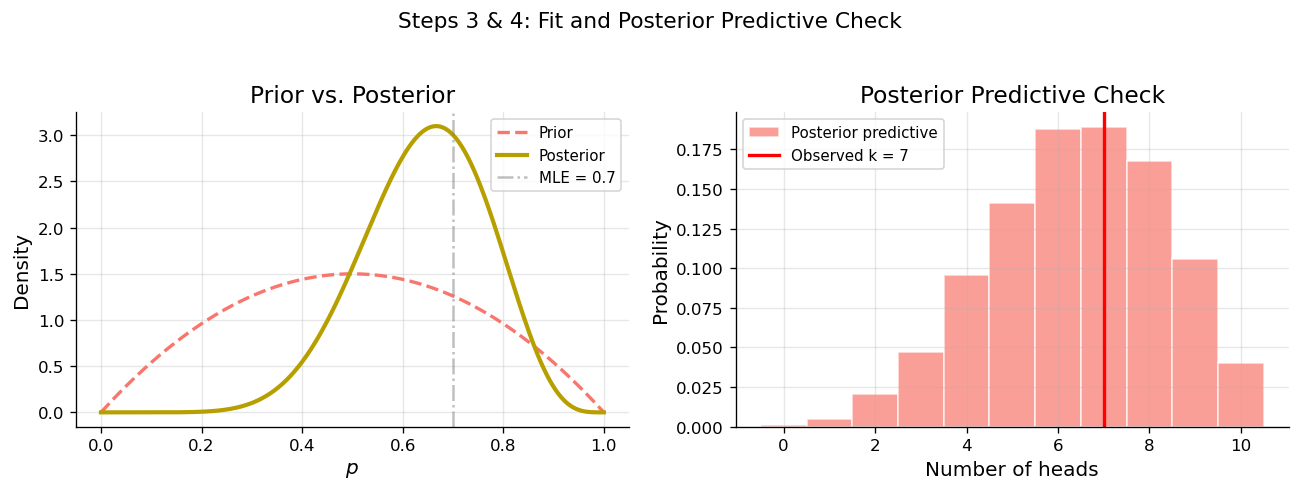

Posterior predictive mean: 6.41 (observed: 7)
Posterior predictive std:  1.93
The model reproduces the observed data well — no obvious misfit.


In [ ]:
# === Step 4: Posterior predictive check ===
# Simulate new datasets from the posterior
p_post_samples = posterior_w.rvs(n_sims, random_state=42)
k_post_pred = np.array([rng.binomial(n_flips, p) for p in p_post_samples])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Posterior on p
p_grid = np.linspace(0, 1, 500)
ax1.plot(
    p_grid, stats.beta(alpha_w, beta_w).pdf(p_grid), "--", linewidth=2, label="Prior"
)
ax1.plot(p_grid, posterior_w.pdf(p_grid), linewidth=2.5, label="Posterior")
ax1.axvline(
    k_heads / n_flips,
    color="gray",
    linestyle="-.",
    alpha=0.5,
    label=f"MLE = {k_heads / n_flips:.1f}",
)
ax1.set_xlabel("$p$")
ax1.set_ylabel("Density")
ax1.set_title("Prior vs. Posterior")
ax1.legend(fontsize=9)

# Posterior predictive
ax2.hist(
    k_post_pred,
    bins=np.arange(-0.5, n_flips + 1.5),
    density=True,
    alpha=0.7,
    edgecolor="white",
    label="Posterior predictive",
)
ax2.axvline(k_heads, color="red", linewidth=2, label=f"Observed k = {k_heads}")
ax2.set_xlabel("Number of heads")
ax2.set_ylabel("Probability")
ax2.set_title("Posterior Predictive Check")
ax2.legend(fontsize=9)

fig.suptitle("Steps 3 & 4: Fit and Posterior Predictive Check", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Posterior predictive mean: {k_post_pred.mean():.2f} (observed: {k_heads})")
print(f"Posterior predictive std:  {k_post_pred.std():.2f}")
print("The model reproduces the observed data well — no obvious misfit.")

The workflow confirms that our model is sensible:
- **Prior predictive check:** The prior generates datasets where 7 heads in 10 flips is plausible (not in the extreme tails).
- **Posterior predictive check:** The fitted model generates new datasets centered around our observation.

If either check had failed — say the prior predictive never produced values near our data, or the posterior predictive showed a systematic mismatch — we would revise the model and iterate.

---

## 7. Animation: Prior Sensitivity

A crucial question in Bayesian inference: **how sensitive is the posterior to the choice of prior?** The answer depends on the amount of data.

The animation below shows three different priors for the coin-flip problem — flat, weakly informative, and informative — updating with the same data. With little data, the priors produce different posteriors. With enough data, they converge.

In [13]:
from manim import *

cfg.apply_manim_config()

from amstats.manim_utils import C, COLORS, PALETTE

math_text = cfg.math_text

Manim Community v0.18.1

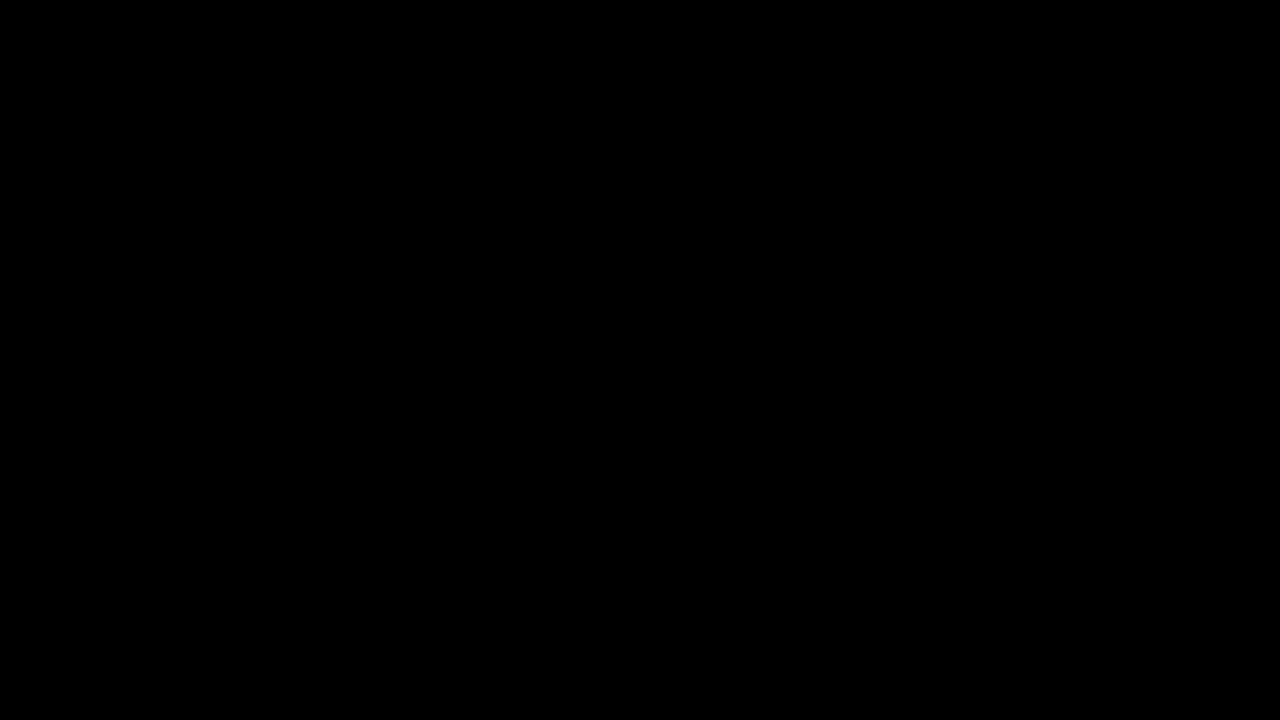

In [14]:
%%manim -qm -v WARNING PriorSensitivity


class PriorSensitivity(Scene):
    """Show 3 priors updating with the same coin-flip data.

    Demonstrates that priors converge with enough data but diverge with little data.
    Colors: SALMON (flat), PERIWINKLE (weakly informative), EMERALD (informative).
    """

    def construct(self):
        from scipy.stats import beta as beta_dist

        title = Text(
            "Prior Sensitivity: How Priors Converge with Data", font_size=26
        ).to_edge(UP)
        self.play(Write(title), run_time=1)

        # Axes
        axes = Axes(
            x_range=[0, 1, 0.2],
            y_range=[0, 12, 2],
            x_length=9,
            y_length=4.5,
            axis_config={"include_numbers": True, "font_size": 20},
        ).shift(DOWN * 0.4)
        x_label = axes.get_x_axis_label(
            math_text(r"p", font_size=24), edge=DOWN, direction=DOWN
        )
        y_label = axes.get_y_axis_label(
            Text("Density", font_size=20), edge=LEFT, direction=LEFT
        )
        self.play(Create(axes), Write(x_label), Write(y_label), run_time=1)

        # Three priors
        priors = [
            {"a": 1, "b": 1, "color": C.SALMON, "name": "Flat: Beta(1,1)"},
            {"a": 2, "b": 2, "color": C.PERIWINKLE, "name": "Weak: Beta(2,2)"},
            {"a": 10, "b": 10, "color": C.EMERALD, "name": "Informative: Beta(10,10)"},
        ]

        # True p for data generation
        true_p = 0.65
        np.random.seed(123)
        all_flips = np.random.binomial(1, true_p, size=200)

        def make_curve(a_param, b_param, color, x_range_plot=(0.01, 0.99)):
            dist = beta_dist(a_param, b_param)
            curve = axes.plot(
                lambda x: dist.pdf(x),
                x_range=list(x_range_plot),
                color=color,
                stroke_width=3,
            )
            return curve

        # Legend
        legend_items = VGroup()
        for i, pr in enumerate(priors):
            dot = Dot(color=pr["color"], radius=0.06)
            label = Text(pr["name"], font_size=16, color=pr["color"])
            row = VGroup(dot, label).arrange(RIGHT, buff=0.15)
            legend_items.add(row)
        legend_items.arrange(DOWN, aligned_edge=LEFT, buff=0.15)
        legend_items.to_corner(UR).shift(DOWN * 0.7)
        self.play(FadeIn(legend_items), run_time=0.5)

        # Draw initial priors
        curves = []
        for pr in priors:
            curve = make_curve(pr["a"], pr["b"], pr["color"])
            curves.append(curve)
            self.play(Create(curve), run_time=0.5)

        # Data counter
        data_label = Text("n = 0, k = 0", font_size=22, color=C.GOLD).to_edge(
            DOWN, buff=0.4
        )
        self.play(Write(data_label), run_time=0.3)

        # Sequentially update with data batches
        data_points = [1, 2, 5, 10, 25, 50, 100, 200]

        for n_data in data_points:
            flips_so_far = all_flips[:n_data]
            k_so_far = int(flips_so_far.sum())

            new_curves = []
            for i, pr in enumerate(priors):
                a_post = pr["a"] + k_so_far
                b_post = pr["b"] + n_data - k_so_far
                new_curve = make_curve(a_post, b_post, pr["color"])
                new_curves.append(new_curve)

            new_data_label = Text(
                f"n = {n_data}, k = {k_so_far}",
                font_size=22,
                color=C.GOLD,
            ).to_edge(DOWN, buff=0.4)

            anims = [Transform(data_label, new_data_label)]
            for i in range(3):
                anims.append(Transform(curves[i], new_curves[i]))

            self.play(*anims, run_time=0.8)
            self.wait(0.4)

        # Final note
        conclusion = Text(
            "With enough data, all three posteriors converge!",
            font_size=22,
            color=C.GOLD,
        ).next_to(axes, DOWN, buff=0.8)
        self.play(Transform(data_label, conclusion), run_time=0.8)
        self.wait(2)

This animation illustrates a fundamental property of Bayesian inference: **the prior matters most when data is scarce**. With $n = 1$ or $n = 2$, the three posteriors are visibly different. By $n = 200$, they are nearly indistinguishable — the data has overwhelmed the prior. This is why prior sensitivity analysis is especially important for small-sample studies.

Note also that even the "informative" prior centered at $p = 0.5$ eventually shifts to the correct value $p \approx 0.65$ — Bayesian inference is **self-correcting** given enough data.

---

## Exercises

**Exercise 2.1 (Beta-Binomial).** A pharmaceutical company runs a clinical trial. They observe 18 successes out of 50 patients. Using a $\text{Beta}(1, 1)$ prior:
- Compute the posterior distribution analytically.
- Find the posterior mean, median, and 95% credible interval.
- Plot the prior, likelihood (scaled), and posterior on the same axes.
- How would the results change with a $\text{Beta}(5, 5)$ prior? Compute and compare.

**Exercise 2.2 (Normal-Normal).** A factory produces bolts with a known standard deviation of $\sigma = 0.05$ mm. Based on historical data, you believe the mean length is $\mu \sim N(10, 0.1^2)$. You measure 15 bolts and find $\bar{x} = 10.03$.
- Compute the posterior distribution.
- What is the probability that $\mu > 10.02$?
- How many observations would you need for the posterior standard deviation to be below 0.005 mm?

**Exercise 2.3 (Gamma-Poisson).** A website receives an average of $\lambda$ requests per second. You observe counts over 30 one-second intervals: the total is 156 requests. Using a $\text{Gamma}(2, 0.5)$ prior:
- Compute the posterior.
- Find $P(\lambda > 6)$ under the posterior.
- Produce a posterior predictive check: simulate 30 new one-second intervals from the posterior and compare their distribution to the observed data.

**Exercise 2.4 (Prior sensitivity).** For the clinical trial in Exercise 2.1, repeat the analysis with four different priors: $\text{Beta}(0.5, 0.5)$, $\text{Beta}(1, 1)$, $\text{Beta}(5, 5)$, and $\text{Beta}(30, 30)$. Plot all four posteriors on the same axes. At what sample size do the posteriors become practically indistinguishable? (Hint: simulate increasing $n$ and measure posterior KL divergence or simply visual overlap.)

**Exercise 2.5 (Bayesian workflow).** A coin is flipped 20 times and lands heads 15 times. Walk through the complete Bayesian workflow:
1. Choose a prior and justify your choice.
2. Perform a prior predictive check.
3. Compute the posterior.
4. Perform a posterior predictive check.
5. Compute $P(p > 0.5 \mid \text{data})$ — the probability that the coin is biased toward heads.

---

## Key Takeaways

1. **Conjugacy** means the prior and posterior belong to the same distributional family. It gives **closed-form posteriors** without MCMC.
2. The **Beta-Binomial** pair is the most important conjugate family: $\text{Beta}(\alpha, \beta)$ prior + Binomial likelihood = $\text{Beta}(\alpha + k, \beta + n - k)$ posterior. The parameters $\alpha, \beta$ are interpretable as **pseudo-counts**.
3. The **Normal-Normal** pair (known variance) gives a posterior mean that is a **precision-weighted average** of the prior mean and sample mean.
4. The **Gamma-Poisson** pair works analogously for count data, adding observed counts and observation periods.
5. **Prior choice matters**, especially with small samples. Use **weakly informative** priors as a default; use **informative** priors when domain knowledge justifies them; and always check **prior sensitivity**.
6. The **Bayesian workflow** — prior predictive check, fit, posterior predictive check, iterate — is essential for building models you can trust.

**Next:** [03_grid_and_quadratic_approximation.ipynb](03_grid_and_quadratic_approximation.ipynb) — What happens when conjugacy isn't available? We explore computational alternatives: grid approximation and Laplace's method.

In [15]:
# Save final GIFs to media/gifs/ at repo root and clean up local temp render files.
cfg.save_gifs(clean=True)

  ✓ media/gifs/BayesianUpdating@2026-03-19@21-38-46.gif
  ✓ media/gifs/PriorSensitivity@2026-03-19@21-46-08.gif
  ✓ media/gifs/PriorSensitivity_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
